# データの読み込み

In [1]:
import pandas as pd

In [2]:
from google.cloud import bigquery

client = bigquery.Client(project="seikabutu-497407")

In [3]:
query = """
SELECT *
FROM mart_olist.mart_model_features
"""

df_model = client.query(query).to_dataframe()

df_model.head()

/home/kotaro/seikabutu/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,order_id,is_low_score,item_count,total_price,total_freight,total_payment,delivery_days,delay_days,customer_state,payment_type,main_category,purchase_weekday,purchase_hour,freight_ratio
0,6e864b3f0ec71031117ad4cf46b7f2a1,0,1,0.85,18.23,19.08,9,0,RJ,credit_card,construcao_ferramentas_construcao,3,20,21.447059
1,3ee6513ae7ea23bdfab5b9ab60bffcb5,0,1,0.85,18.23,19.08,13,0,SP,boleto,construcao_ferramentas_construcao,3,11,21.447059
2,f1d5c2e6867fa93ceee9ef9b34a53cbf,0,1,2.20,7.39,9.59,3,0,SP,voucher,beleza_saude,7,21,3.359091
3,e8bbc1d69fee39eee4c72cb5c969e39d,0,1,2.29,7.78,10.07,4,0,SP,credit_card,papelaria,4,19,3.397380
4,38bcb524e1c38c2c1b60600a80fc8999,0,1,2.90,8.72,11.62,11,0,PR,boleto,pet_shop,5,12,3.006897


# データ内容確認

In [4]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 95832 entries, 0 to 95831
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          95832 non-null  str    
 1   is_low_score      95832 non-null  Int64  
 2   item_count        95832 non-null  Int64  
 3   total_price       95832 non-null  float64
 4   total_freight     95832 non-null  float64
 5   total_payment     95831 non-null  float64
 6   delivery_days     95824 non-null  Int64  
 7   delay_days        95824 non-null  Int64  
 8   customer_state    95832 non-null  str    
 9   payment_type      95831 non-null  str    
 10  main_category     94462 non-null  str    
 11  purchase_weekday  95832 non-null  Int64  
 12  purchase_hour     95832 non-null  Int64  
 13  freight_ratio     95832 non-null  float64
dtypes: Int64(6), float64(4), str(4)
memory usage: 16.1 MB


In [5]:
df_model.isnull().sum()

order_id               0
is_low_score           0
item_count             0
total_price            0
total_freight          0
total_payment          1
delivery_days          8
delay_days             8
customer_state         0
payment_type           1
main_category       1370
purchase_weekday       0
purchase_hour          0
freight_ratio          0
dtype: int64

In [6]:
df_model["is_low_score"].value_counts(normalize=True)

is_low_score
0    0.871932
1    0.128068
Name: proportion, dtype: Float64

In [7]:
df_model = df_model.dropna()

# 訓練データ、テストデータの準備

In [8]:
X = df_model.drop(
    columns=[
        "order_id",
        "is_low_score"
    ]
)

y = df_model["is_low_score"]

In [9]:
X

,item_count,total_price,total_freight,total_payment,delivery_days,delay_days,customer_state,payment_type,main_category,purchase_weekday,purchase_hour,freight_ratio
0,1,0.85,18.23,19.08,9,0,RJ,credit_card,construcao_ferramentas_construcao,3,20,21.447059
1,1,0.85,18.23,19.08,13,0,SP,boleto,construcao_ferramentas_construcao,3,11,21.447059
2,1,2.20,7.39,9.59,3,0,SP,voucher,beleza_saude,7,21,3.359091
3,1,2.29,7.78,10.07,4,0,SP,credit_card,papelaria,4,19,3.397380
4,1,2.90,8.72,11.62,11,0,PR,boleto,pet_shop,5,12,3.006897
...,...,...,...,...,...,...,...,...,...,...,...,...
95827,6,5934.60,146.94,6081.54,19,0,MG,boleto,agro_industria_e_comercio,6,11,0.024760
95828,1,6499.00,227.66,6726.66,11,0,SP,boleto,artes,4,18,0.035030
95829,1,6735.00,194.31,6929.31,18,0,MS,credit_card,utilidades_domesticas,1,20,0.028851
95830,4,7160.00,114.88,7274.88,11,0,ES,boleto,telefonia_fixa,1,14,0.016045


In [10]:
y

0        0
1        0
2        0
3        0
4        0
        ..
95827    1
95828    0
95829    0
95830    1
95831    1
Name: is_low_score, Length: 94453, dtype: Int64

### データの分割

In [11]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ロジスティック回帰モデル

In [14]:
from sklearn.linear_model import LogisticRegression

model_scaled = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model_scaled.fit(
    X_train_scaled,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [15]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

pred_scaled = model_scaled.predict(X_test_scaled)

print("=== Scaled ===")
print(classification_report(y_test, pred_scaled))

=== Scaled ===
              precision    recall  f1-score   support

         0.0       0.93      0.83      0.88     16484
         1.0       0.33      0.56      0.41      2407

    accuracy                           0.80     18891
   macro avg       0.63      0.70      0.65     18891
weighted avg       0.85      0.80      0.82     18891



# 性能評価

In [16]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

result = pd.DataFrame({
    "model": "Logistic_scaled",
    "accuracy": [
        accuracy_score(y_test, pred_scaled)
    ],
    "precision": [
        precision_score(y_test, pred_scaled)
    ],
    "recall": [
        recall_score(y_test, pred_scaled)
    ],
    "f1": [
        f1_score(y_test, pred_scaled)
    ]
})

result

,model,accuracy,precision,recall,f1
0,Logistic_scaled,0.796623,0.327233,0.564603,0.414329


In [17]:
pred_scaled = model_scaled.predict(X_test_scaled)

pd.Series(pred_scaled).value_counts()

0.0    14738
1.0     4153
Name: count, dtype: int64

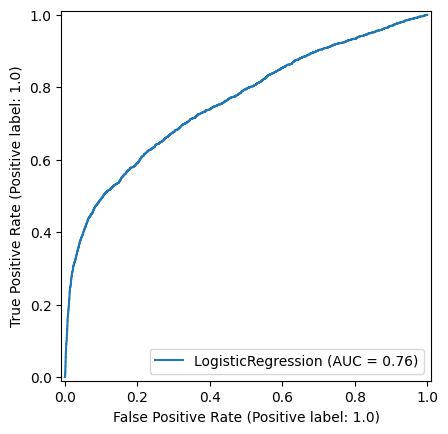

In [18]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    model_scaled,
    X_test_scaled,
    y_test
)
plt.show()

# ランダムフォレストモデル

In [19]:
from sklearn.ensemble import RandomForestClassifier

In [20]:
rf = RandomForestClassifier(
     n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [21]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [22]:
y_pred = rf.predict(X_test)

In [23]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

y_proba = rf.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

         0.0       0.93      0.88      0.90     16484
         1.0       0.39      0.53      0.45      2407

    accuracy                           0.83     18891
   macro avg       0.66      0.70      0.68     18891
weighted avg       0.86      0.83      0.84     18891

[[14474  2010]
 [ 1131  1276]]
ROC-AUC: 0.7650612995119488


In [24]:
import pandas as pd

importance_df = pd.DataFrame({
    "feature":X_train.columns,
    "importance":rf.feature_importances_
})

importance_df.sort_values(
    "importance",
    ascending=False
).head(20)

,feature,importance
5,delay_days,0.260091
4,delivery_days,0.197888
2,total_freight,0.081705
0,item_count,0.070236
3,total_payment,0.063927
8,freight_ratio,0.063213
1,total_price,0.060037
7,purchase_hour,0.042352
6,purchase_weekday,0.027787
27,customer_state_RJ,0.009149


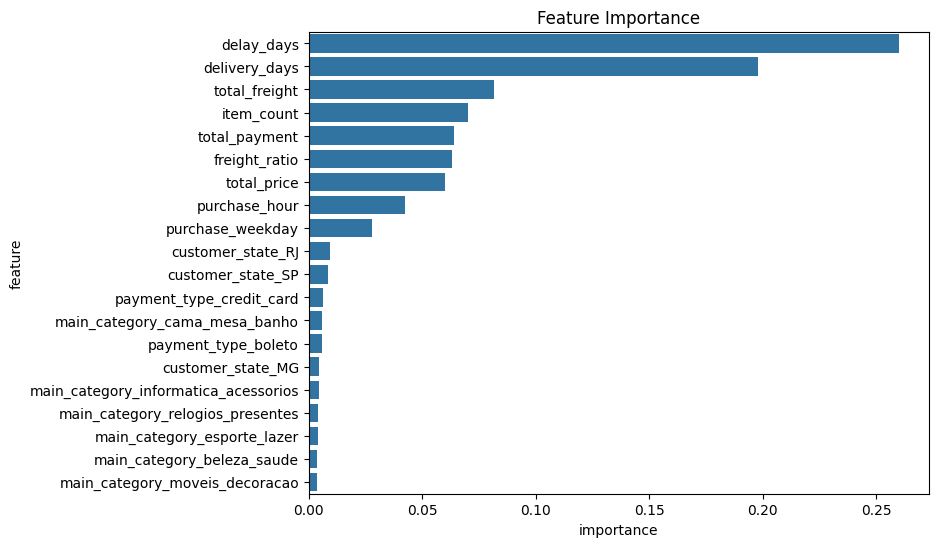

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

top20 = (
    importance_df.sort_values("importance", ascending=False).head(20)
)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top20,
    x="importance",
    y="feature"
)

plt.title("Feature Importance")
plt.show()

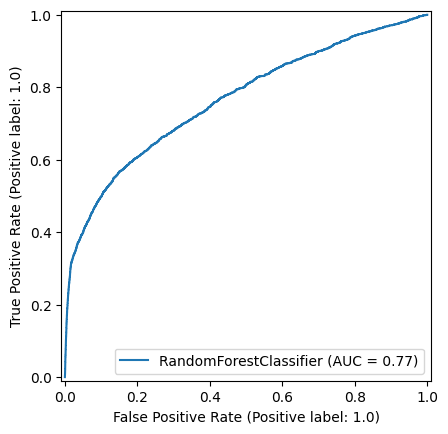

In [26]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test
)
plt.show()

# XGBoost

In [28]:
from xgboost import XGBClassifier

model_xg = XGBClassifier(
    scale_pos_weight=6.8,
    random_state=42,
    n_estimators=300,
    max_depth=5
)

model_xg.fit(X_train, y_train)

pred_xg = model_xg.predict(X_test)

In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_xg))

              precision    recall  f1-score   support

         0.0       0.92      0.85      0.89     16484
         1.0       0.34      0.53      0.41      2407

    accuracy                           0.81     18891
   macro avg       0.63      0.69      0.65     18891
weighted avg       0.85      0.81      0.83     18891



In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_xg)
print(cm)

[[14042  2442]
 [ 1142  1265]]


In [31]:
from sklearn.metrics import roc_auc_score

proba_xg = model_xg.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, proba_xg)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7465633732076639


In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

proba_xg = model_xg.predict_proba(X_test)[:, 1]

result = {
    "accuracy": accuracy_score(y_test, pred_xg),
    "precision": precision_score(y_test, pred_xg),
    "recall": recall_score(y_test, pred_xg),
    "f1": f1_score(y_test, pred_xg),
    "roc_auc": roc_auc_score(y_test, proba_xg)
}

print(result)

{'accuracy': 0.8102800275263353, 'precision': 0.34124629080118696, 'recall': 0.5255504777731617, 'f1': 0.41380438338240105, 'roc_auc': 0.7465633732076639}


In [33]:
import pandas as pd

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_xg.feature_importances_
})

importance_df.sort_values(
    "importance",
    ascending=False
).head(20)

,feature,importance
5,delay_days,0.175633
0,item_count,0.076113
84,main_category_informatica_acessorios,0.013066
99,main_category_papelaria,0.012778
53,main_category_cama_mesa_banho,0.012726
49,main_category_bebes,0.012602
80,main_category_ferramentas_jardim,0.012242
88,main_category_livros_interesse_geral,0.012195
90,main_category_malas_acessorios,0.011761
34,customer_state_SP,0.011326


# SHAP

In [37]:
import shap

explainer = shap.TreeExplainer(rf)

In [39]:
X_sample = X_test.sample(
    100,
    random_state=42
)

shap_values = explainer.shap_values(X_sample)

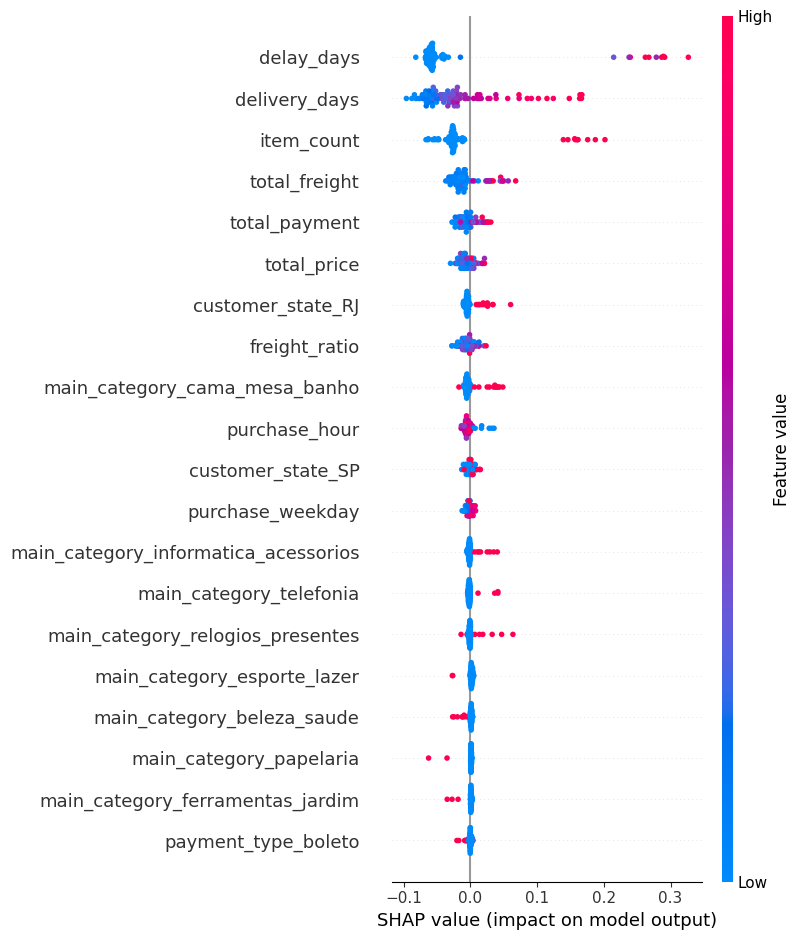

In [40]:
shap.summary_plot(
    shap_values[:,:,1],
    X_sample
)

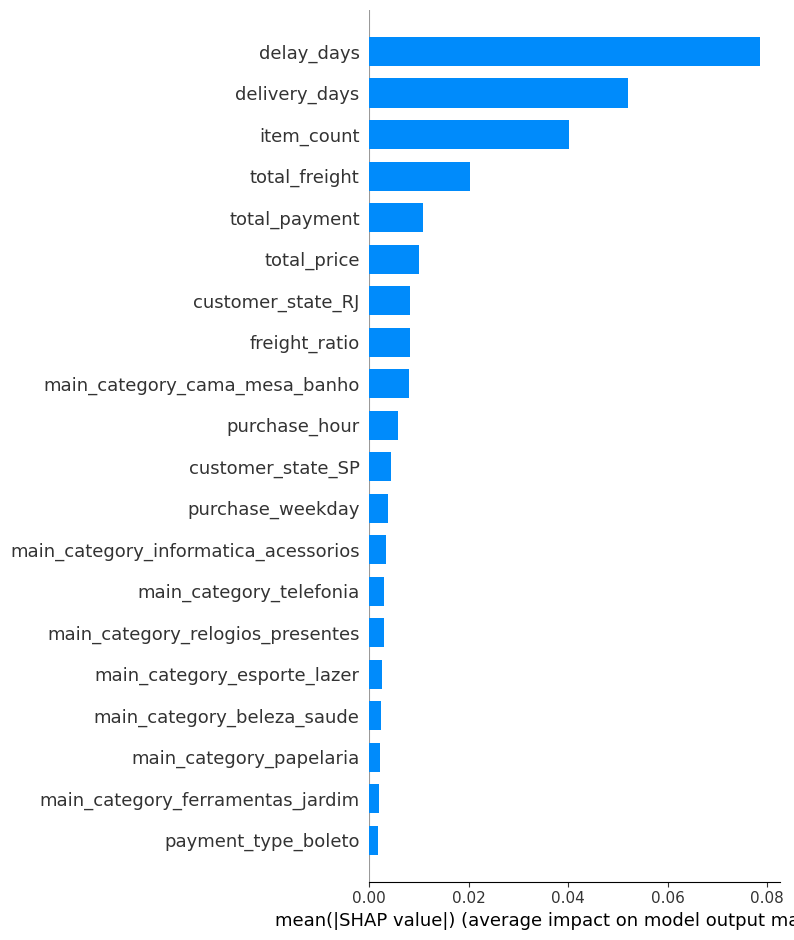

In [41]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_sample,
    plot_type="bar"
)